# Multi-Model Switching with Contact

**RQ2 handover.** What does the state transfer cost when the two models use
different representations?

Three backends behind one interface — FEM, OpenSim, and an FMU — switched by an
ordered region map on the pendulum angle, against a monolithic OpenModelica
reference. This is the notebook that measures the handover itself: every
committed transfer carries a report, and the quantities that the canonical
interface does *not* carry are the ones that price it.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

sys.path.insert(0, str(Path.cwd().resolve()))
from evidence import repo_root

REPO = repo_root()

import evidence as ev
from plot_setup import FULL_WIDTH, set_professional_style
from record import record, paper_results_dir

plt = set_professional_style(latex=True)

# Recorded numbers belong to the paper repository, not to this one.
RESULTS, _results_source = paper_results_dir(REPO)
print(f"repository root resolved: {REPO.name}")
print(f"results destination      : {_results_source}")

repository root resolved: SystemSimulation
results destination      : sibling SysSimX-Framework-Paper checkout


In [2]:
# Pin the OpenModelica toolchain. OMPython resolves omc through OPENMODELICAHOME
# and PATH, so a second installation silently changes which compiler builds the
# reference - and therefore the trajectory every error below is measured against.
import os

OM_VERSION_EXPECTED = "1.26.3"
OM_HOME = Path(os.environ.get("SYSSIMX_OM_HOME", r"C:\Program Files\OpenModelica1.26.3-64bit"))
if next((c for c in (OM_HOME / "bin/omc.exe", OM_HOME / "bin/omc") if c.is_file()), None) is None:
    raise FileNotFoundError(f"No OpenModelica compiler under {OM_HOME}. Set SYSSIMX_OM_HOME.")
os.environ["OPENMODELICAHOME"] = str(OM_HOME)

from OMPython import OMCSessionZMQ

om_version = OMCSessionZMQ().sendExpression("getVersion()")
print(f"OpenModelica : {om_version}")
if OM_VERSION_EXPECTED not in om_version:
    raise RuntimeError(
        f"Expected OpenModelica {OM_VERSION_EXPECTED}, got {om_version}. The reference is only "
        f"comparable within one toolchain: set SYSSIMX_OM_HOME and OM_VERSION_EXPECTED together."
    )

OpenModelica : OpenModelica v1.26.3 (64-bit)


## Configuration

The scenario is the shared contact configuration. The launch gate is what keeps
the expensive deformable model out of the window where the pendulum is
accelerating away from the wall and cannot contact anything.

In [3]:
# CONTACT_SCENARIO's tol_time is 1.5e-4, chosen for the *performance* notebook:
# it sits above the FEM's own 1e-4 s contact sub-step so `_locate_event_time`
# accepts the bracket the FEM already reported and skips bisection, at about
# four fewer FEM solves per event. That trade is right when the quantity is
# time. Here the quantity is agreement with the reference, and repeated impacts
# amplify sub-millisecond timing differences (issues.md EVID-03): at 1.5e-4 this
# run located 3 of the reference's 5 contacts, with two of them ~37 ms adrift.
# Campaign B horizon, settled 2026-09-12 at 1.0 s. It reaches the third contact
# cluster, whose rebounds in the monolithic reference are higher than the first
# two, while 2.0 s only adds impacts of an idealised penalty-contact model.
HORIZON_S = 1.0

# HYB-01 hit this scenario at the 2 s horizon on 2026-09-12: boundary 1 fell
# out of the FMU region without being localized, so the wrapper stayed in
# region 2 and the next boundary-0 crossing was refused as a two-region jump.
# Fatal guarding turns that into a message naming the indicator and the instant,
# instead of a region error one boundary later. Turn it off once HYB-01 is
# fixed, or when a run must complete rather than diagnose.
# One NGSolve thread makes the FEM bit-identical run to run (06_determinism,
# within and across processes). Six threads and the default do not.
# Launch gate for the three-region map, settled 2026-09-14. The shared 0.35 rad
# offset was tuned for the two-region FEM/FMU map of 04_performance: here it put
# the key above 15 deg at t0, started the run in FMU, and the decaying key then
# drove an FMU -> OpenSim -> FMU pair before any physical approach. At 0.15 rad
# the key starts inside OpenSim (initial region = bisect_right(breakpoints,
# key)), and over the ramp it stays within 0.106 .. 0.150 rad, clear of both
# OpenSim edges 0.070 and 0.279. The first switch, OpenSim -> FMU at 0.052 s, is
# then driven by the swing itself.
SCENARIO = ev.CONTACT_SCENARIO.replace(
    event_tol_time=1e-5, t_end=HORIZON_S, raise_on_missed_event=True,
    ngsolve_threads=1, gate_offset_rad=0.15,
)
OUT_DIR = REPO / "notebooks" / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PACKAGE = REPO / "demos" / "ControlledPendulum" / "src" / "modelica" / "ControlledPendulum"
REFERENCE_MODEL = "ControlledPendulum.Examples.Contact.RigidContact"
FMU_PATHS = ev.discover_fmus(REPO, sys.platform)

display(pd.Series(SCENARIO.provenance()).to_frame("value"))

,value
name,contact
contact,True
t0,0.0
t_end,1.0
macro_dt,0.001
fem_internal_dt,0.001
switch_threshold_rad,0.075
switch_band_rad,0.005
region_modes,"[FEM, FMU]"
gate_t_open_s,0.03


## Monolithic reference

In [4]:
from OMPython import ModelicaSystem

reference = ModelicaSystem(
    fileName=str(PACKAGE / "package.mo"), modelName=REFERENCE_MODEL, omhome=str(OM_HOME)
)
reference.setParameters({"useReset": "true"})
reference.buildModel()
reference.simulate(simargs={"stopTime": SCENARIO.t_end,})

REF_SIGNALS = ("time", "theta", "theta_ref", "u_control", "pid.I_out", "pendulum.contact")
ref = {name: reference.getSolutions(name).flatten() for name in REF_SIGNALS}

# Reference contact instants are the *rising edges* of the contact flag, not
# every second sample of it: the flag stays high for the whole contact phase, so
# a fixed stride silently mislabels the events it pairs up.
flag = np.asarray(ref["pendulum.contact"]) > 0
edges = np.flatnonzero(np.diff(flag.astype(int)) == 1) + 1
ref_contact_times = ref["time"][edges]
ref_contact_times = ref_contact_times[ref_contact_times <= SCENARIO.t_end]
print(f"reference contacts within the horizon: {len(ref_contact_times)}")

[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


[OMC log for 'sendExpression(buildModel(ControlledPendulum.Examples.Contact.RigidContact, variableFilter=".*"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


reference contacts within the horizon: 14


## Plant

`MasterPendulum` builds all three backends and owns its region map. Only the
region *key* is overridden, to add the launch gate; the gate reads the active
sub-model's clock because `HybridAlgorithm` calls `_do_step_internal` directly
for trial steps and bisection, which never advances the wrapper's own `t`.

In [5]:
from syssimx_examples.controlled_pendulum import MasterPendulum

REGION_GATE = ev.TimeGatedRegionKey(
    offset=SCENARIO.gate_offset_rad, t_open=SCENARIO.gate_t_open_s
)


class GatedMasterPendulum(MasterPendulum):
    '''`MasterPendulum` whose region key is gated through the launch window.'''

    @staticmethod
    def _absolute_theta(component):
        return REGION_GATE(component)


def run_once(label):
    """One complete switched run, returned as plain data.

    A fresh plant every time: repeated runs must not share state. Everything the
    tables below need is returned, because the system itself is not kept.
    """
    plant = GatedMasterPendulum(name="MasterPendulum", initial_mode="OpenSim")
    plant.record_switch_state = True
    plant.set_parameters(**{"FEM": ev.make_fem_parameters(SCENARIO)})
    system, plant = ev.assemble_system(
        plant, SCENARIO, FMU_PATHS, case_name="Multi-Model Switching"
    )
    initial_mode = plant.active_mode

    with tqdm(total=SCENARIO.sim_time, desc=label, unit=" sim s", leave=False) as bar:
        seen = SCENARIO.t0

        def advance(t_now, _t_final):
            nonlocal seen
            now = min(max(t_now, SCENARIO.t0), SCENARIO.t_end)
            bar.update(now - seen)
            seen = now

        system.run(SCENARIO.t0, SCENARIO.t_end, SCENARIO.macro_dt, progress=advance)

    history = system.get_history()
    t_plant, data_plant = history[plant.name]
    t_plant = np.asarray(t_plant, dtype=float)
    theta_plant = np.asarray(data_plant["theta"], dtype=float)
    contact_times = ev.contact_event_times(system, plant)

    transfers = pd.DataFrame([
        {
            "t": float(e.time), "from": e.from_mode, "to": e.to_mode,
            "d_theta": e.transfer_report.theta_error,
            "d_omega": e.transfer_report.omega_error,
            "d_tau": e.transfer_report.tau_error,
            "d_alpha": e.transfer_report.alpha_error,
            "d_energy": e.transfer_report.energy_error,
            "elastic_lost": e.transfer_report.elastic_energy_lost,
            # evidence_plan.md section 4 asks for momentum beside energy. All three
            # backends are synchronized to one rigid parameter set at
            # initialization, so L = J * omega with a single J, and the angular
            # momentum jump is exactly J * omega_error. omega is an *enforced*
            # invariant, so this column is a rescaling of a bounded quantity and
            # carries no evidence the omega column does not already carry. It is
            # recorded because the plan asks for the number, and it is grouped
            # with the enforced quantities so section 6.2 cannot read it as free.
            "d_momentum": plant.rigid_properties.inertia * e.transfer_report.omega_error,
            "violations": ", ".join(
                e.transfer_report.violations(plant.transfer_tolerances)
            ) or "-",
        }
        for e in plant.switch_events
    ])

    abs_theta = np.abs(theta_plant)
    boundaries = plant.switch_regions.boundaries
    rows = []
    for (_comp, event_name), records in history["Events"].items():
        if not event_name.startswith("region_boundary_"):
            continue
        boundary = boundaries[int(event_name.rsplit("_", 1)[1])]
        for rec in records:
            t_event = float(rec.t)
            # The key is the gated signal, not abs(theta): before gate_t_open_s
            # the two differ by the decaying offset, and the armed threshold is
            # compared against the key the algorithm actually saw.
            key = REGION_GATE.value(t_event, float(np.interp(t_event, t_plant, abs_theta)))
            armed = (boundary.upper_threshold if key >= boundary.breakpoint
                     else boundary.lower_threshold)
            committed = [e for e in plant.switch_events if abs(e.time - t_event) <= 1e-12]
            rows.append({
                "t": t_event, "boundary": event_name, "armed": armed, "key": key,
                "residual": key - armed,
                "off_grid": ev.distance_to_grid(t_event, SCENARIO.macro_dt),
                "switch": (f"{committed[0].from_mode} -> {committed[0].to_mode}"
                           if committed else "-"),
            })
    localization = pd.DataFrame(rows).sort_values("t").reset_index(drop=True)

    return {
        "plant": plant,
        "initial_mode": initial_mode,
        "t": t_plant,
        "theta": theta_plant,
        "contact_times": contact_times,
        "transfers": transfers,
        "localization": localization,
        "intervals": ev.mode_intervals(
            plant.switch_events, initial_mode, SCENARIO.t0, SCENARIO.t_end
        ),
    }


## Run

In [6]:
# REPRO-02: the FEM is not run-to-run reproducible with NGSolve threading left
# at its default. Superseded 2026-09-13: this notebook pins NGSolve to one
# thread, which 06_determinism verified bit-identical, so a single run is the
# measurement. Five repetitions remain the rule only for an unpinned run.
#
# CAMPAIGN selects what this run is for, and the repetition count follows.
#
# Off: one repetition. Section 6.1 needs only the off-grid offset and the
# indicator residual, which are properties of the algorithm against a single
# trajectory and do not aggregate, so repeating buys nothing.
#
# On: five. That is the floor in evidence_plan.md section 6 - "a warm-up plus at
# least five repetitions" - and it is a floor rather than a target: REPRO-02
# notes the scatter concentrates in marginal events that are "rare enough to
# miss in a handful of repetitions". Five makes the spread reportable; it does
# not make a rare divergence unlikely. Raise it if section 6.2 ends up quoting a
# quantity whose spread matters more than its median.
#
# Cost is linear in the repetition count: each one is a full switched run.
CAMPAIGN = True
N_REPEATS = 1 if SCENARIO.ngsolve_threads == 1 else (5 if CAMPAIGN else 1)

repeats = [run_once(f"repeat {i + 1}/{N_REPEATS}") for i in range(N_REPEATS)]

# The first repetition is the representative one for the figures; it is not
# more correct than the others, only the one that gets drawn.
rep = repeats[0]
plant, intervals = rep["plant"], rep["intervals"]
t_plant, theta_plant = rep["t"], rep["theta"]
contact_times = rep["contact_times"]
initial_mode = rep["initial_mode"]

counts = pd.DataFrame([
    {"repeat": i + 1,
     "switches": len(r["transfers"]),
     "contacts": len(r["contact_times"]),
     "max_|residual|_rad": r["localization"]["residual"].abs().max(),
     "min_off_grid_s": r["localization"]["off_grid"].min()}
    for i, r in enumerate(repeats)
])
display(counts.style.format({
    "max_|residual|_rad": "{:.3e}", "min_off_grid_s": "{:.3e}"}).hide(axis="index"))

print(f"reconciled initial mode : {initial_mode}")

# The launch gate must select the starting model, not drive switches.
assert initial_mode == "OpenSim", f"expected to start in OpenSim, got {initial_mode}"
_gate_driven = [e for e in plant.switch_events if float(e.time) <= SCENARIO.gate_t_open_s]
assert not _gate_driven, (
    f"{len(_gate_driven)} switch(es) inside the {SCENARIO.gate_t_open_s} s launch ramp: "
    + ", ".join(f"{e.from_mode}->{e.to_mode}@{float(e.time):.4f}" for e in _gate_driven)
)
print(f"reference contacts      : {len(ref_contact_times)}")


repeat 1/1:   0%|          | 0/1.0 [00:00<?, ? sim s/s]

repeat,switches,contacts,max_|residual|_rad,min_off_grid_s
1,12,14,1.627e-04,3.487e-16


reconciled initial mode : FMU
reference contacts      : 14


## T1 — per-switch transfer report

Two groups of quantities, read differently.

`theta`, `omega` and `tau` are **enforced** invariants: the transaction raises
and rolls back when any of them jumps further than its tolerance, so a completed
run cannot show a violation. Their columns confirm the contract held; they are
not a measurement of handover quality.

`alpha` and the energy terms are **measured but not enforced**, because the
canonical interface carries angular position, velocity and torque only. Those are
the quantities that actually price a handover. `elastic_lost` is the strain
energy present in the FEM state and absent from the rigid target — the projection
loss of leaving the deformable model.

`d_momentum` sits with the **enforced** group, not with the free measurements.
Every backend is synchronized to one rigid parameter set, so angular momentum is
`J * omega` with a single `J` and its jump is exactly `J` times the enforced
`omega` residual. The column answers the conserved-quantity question asked in
`evidence_plan.md` section 4. It is not independent evidence for RQ2, and section
6.2 must not quote it beside `d_alpha` and the energy terms as though it were.

In [7]:
# --- what survives repetition ----------------------------------------------
# The enforced invariants are bounded by the transaction: any completed run
# shows the contract held, so they confirm the contract and measure nothing.
# The free measurements - angular acceleration and the energy terms - are
# physics quantities that vary between identical runs under REPRO-02, so they
# are reported as a median over repetitions with the observed spread.

for i, r in enumerate(repeats):
    assert not (r["transfers"]["violations"] != "-").any(), (
        f"repeat {i + 1}: a transfer violated its declared tolerance"
    )

# Structural stability first. If the runs do not agree on how many switches and
# contacts occurred, no per-transfer aggregate is meaningful.
switch_counts = sorted({len(r["transfers"]) for r in repeats})
contact_counts = sorted({len(r["contact_times"]) for r in repeats})
print(f"switches across repeats : {switch_counts}")
print(f"contacts across repeats : {contact_counts}")
# D6, settled 2026-09-12: when the repetitions disagree, report the
# disagreement. Do not shorten the horizon and do not aggregate across different
# event sequences. This used to raise, which discarded a five-repetition run at
# the point D6 says is a result.
sequence_groups = {}
for i, r in enumerate(repeats):
    sequence_groups.setdefault(
        (len(r["transfers"]), len(r["contact_times"])), []
    ).append(i + 1)
repeats_agree = len(sequence_groups) == 1

if not repeats_agree:
    print("\nREPRO-02: the repetitions resolved different event sequences.")
    for (n_sw, n_ct), members in sorted(sequence_groups.items()):
        print(f"  {n_sw:3d} switches, {n_ct:3d} contacts : repeats {members}")
    # Aggregate only within the largest group that shares one sequence. Mixing
    # sequences would average handovers that are not the same handover.
    modal = max(sequence_groups.items(), key=lambda kv: (len(kv[1]), -kv[0][0]))
    aggregated_repeats = [repeats[i - 1] for i in modal[1]]
    print(f"  aggregating the {len(aggregated_repeats)} repeats with "
          f"{modal[0][0]} switches; the others are reported, not averaged")
else:
    aggregated_repeats = repeats

# Directed transfers are the unit of aggregation: the same handover in every run.
free = pd.concat(
    [r["transfers"].assign(repeat=i) for i, r in enumerate(aggregated_repeats)],
    ignore_index=True,
)
free["directed"] = free["from"] + " -> " + free["to"]

handovers = free.groupby("directed", sort=False).agg(
    n=("repeat", "nunique"),
    t_median=("t", "median"),
    t_spread=("t", lambda s: s.max() - s.min()),
    d_alpha_median=("d_alpha", "median"),
    d_alpha_spread=("d_alpha", lambda s: s.max() - s.min()),
    elastic_median=("elastic_lost", "median"),
    elastic_spread=("elastic_lost", lambda s: s.max() - s.min()),
)
display(handovers.style.format({
    "t_median": "{:.6f}", "t_spread": "{:.2e}",
    "d_alpha_median": "{:.3e}", "d_alpha_spread": "{:.2e}",
    "elastic_median": "{:.3e}", "elastic_spread": "{:.2e}",
}))

# The noise band: how much does an identical run move the quantity that carries
# the evidence? Quote this beside any handover number.
alpha_band = float(handovers["d_alpha_spread"].max())
alpha_level = float(handovers["d_alpha_median"].abs().max())
print(f"largest |d_alpha| median : {alpha_level:.3e} rad/s^2")
print(f"largest d_alpha spread   : {alpha_band:.3e} rad/s^2 "
      f"({alpha_band / alpha_level:.1%} of the level)" if alpha_level else "")
if N_REPEATS == 1 and SCENARIO.ngsolve_threads == 1:
    print("n = 1 with NGSolve pinned to one thread. The run is bit-identical on "
          "repetition (06_determinism), so the spread columns are zero by "
          "construction and the medians are the measurement.")
elif N_REPEATS == 1:
    print("NOTE: n = 1 with NGSolve unpinned. The spread column is zero because "
          "nothing was repeated, not because the run is reproducible. These handover "
          "numbers are a single draw and must not be quoted in section 6.2.")
elif alpha_band > 0.25 * alpha_level:
    print("NOTE: run-to-run spread exceeds a quarter of the level. Quote the median "
          "with the spread, never a single run (issues.md REPRO-02).")


switches across repeats : [12]
contacts across repeats : [14]


,n,t_median,t_spread,d_alpha_median,d_alpha_spread,elastic_median,elastic_spread
directed,,,,,,,
FMU -> OpenSim,1,0.299270,7.89e-01,5.684e-14,5.68e-14,0.000e+00,0.00e+00
OpenSim -> FMU,1,0.385297,6.69e-01,5.684e-14,5.68e-14,0.000e+00,0.00e+00
OpenSim -> FEM,1,0.495195,6.67e-01,1.705e-13,3.41e-13,-6.612e-19,5.97e-20
FEM -> OpenSim,1,0.520578,3.40e-01,5.934e-05,3.91e-05,5.415e-06,9.64e-06


largest |d_alpha| median : 5.934e-05 rad/s^2
largest d_alpha spread   : 3.906e-05 rad/s^2 (65.8% of the level)
n = 1 with NGSolve pinned to one thread. The run is bit-identical on repetition (06_determinism), so the spread columns are zero by construction and the medians are the measurement.


### Trajectory of one repetition

Under REPRO-02 the repetitions are not identical runs, so a single trajectory is
one draw. Pick the repeat with `SHOW_REPEAT` and read the figure as an example of
the mechanism, not as the result.


repeat 1/1: 12 switches, 14 contacts, initial mode FMU
modes visited: FMU -> OpenSim -> FMU -> OpenSim -> FEM -> OpenSim -> FMU -> OpenSim -> FEM -> OpenSim -> FMU -> OpenSim -> FEM


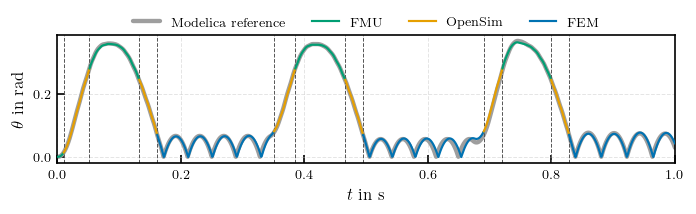

In [8]:
from plot_setup import MODEL_COLORS, REFERENCE_STYLE

# 1-based, to match the "repeat i/N" labels the run cell prints.
SHOW_REPEAT = min(5, len(repeats))
_r = repeats[SHOW_REPEAT - 1]

fig, ax = plt.subplots(figsize=(FULL_WIDTH, 0.34 * FULL_WIDTH))

ax.plot(ref["time"], ref["theta"], label="Modelica reference", **REFERENCE_STYLE)

# One coloured segment per active model, so the mode is readable from the curve
# itself rather than from a separate band.
for t_start, t_stop, mode in _r["intervals"]:
    span = (_r["t"] >= t_start) & (_r["t"] <= t_stop)
    ax.plot(_r["t"][span], _r["theta"][span], color=MODEL_COLORS[mode],
            linewidth=1.3, solid_capstyle="round", zorder=3)

for mode in dict.fromkeys(m for _, _, m in _r["intervals"]):
    ax.plot([], [], color=MODEL_COLORS[mode], linewidth=1.3, label=mode)

for t_switch in _r["transfers"]["t"]:
    ax.axvline(float(t_switch), color="0.35", linestyle="--", linewidth=0.6, zorder=2)

ax.set_xlabel(r"$t$ in $\mathrm{s}$")
ax.set_ylabel(r"$\theta$ in $\mathrm{rad}$")
ax.set_xlim(SCENARIO.t0, SCENARIO.t_end)
ax.grid(True, alpha=0.4)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.24), ncol=4,
          fontsize=8, frameon=False)

n_sw = len(_r["transfers"])
n_ct = len(_r["contact_times"])
print(f"repeat {SHOW_REPEAT}/{len(repeats)}: {n_sw} switches, {n_ct} contacts, "
      f"initial mode {_r['initial_mode']}")
print("modes visited:", " -> ".join(m for _, _, m in _r["intervals"]))

fig.tight_layout()
fig.savefig(OUT_DIR / f"F3c_repeat{SHOW_REPEAT}{'' if CAMPAIGN else '.smoke'}.pdf",
            bbox_inches="tight")
plt.show()


### Bounce envelope, and whether the region contains it

The FEM region is entered at the lower armed edge and left at the upper one, so
the whole contact episode has to fit below the upper edge. If a bounce peak
reaches it, the run leaves FEM mid-episode and comes straight back, which is one
extra switch pair and is what makes the repetitions disagree under REPRO-02.

The envelope is the largest `|theta|` between two consecutive contacts. Intervals
longer than a quarter of the setpoint period are the large swings between contact
clusters, not bounces, so they are discarded.


In [9]:
# Gaps longer than this separate contact clusters; the peak inside one of those
# is the driven swing, not a bounce.
SETPOINT_PERIOD_S = 1.0 / SCENARIO.setpoint_freq_hz
CLUSTER_GAP_S = 0.25 * SETPOINT_PERIOD_S

envelope_rows = []
for k, r in enumerate(repeats, start=1):
    contacts = np.asarray(r["contact_times"], dtype=float)
    t, theta = r["t"], np.abs(r["theta"])
    for t_a, t_b in zip(contacts[:-1], contacts[1:]):
        if (t_b - t_a) >= CLUSTER_GAP_S:
            continue  # a driven swing between clusters
        span = (t >= t_a) & (t <= t_b)
        if not span.any():
            continue
        envelope_rows.append({"repeat": k, "t_a": t_a, "t_b": t_b,
                              "gap": t_b - t_a, "peak": float(theta[span].max())})

envelope = pd.DataFrame(envelope_rows)
boundary = plant.switch_regions.boundaries[0]
lower, upper = boundary.lower_threshold, boundary.upper_threshold

n_total = sum(max(len(r["contact_times"]) - 1, 0) for r in repeats)
print(f"setpoint period      : {SETPOINT_PERIOD_S:.4f} s, cluster gap cut at "
      f"{CLUSTER_GAP_S:.4f} s")
print(f"intervals            : {len(envelope)} kept of {n_total} "
      f"({n_total - len(envelope)} discarded as inter-cluster swings)")

if envelope.empty:
    print("No intra-cluster interval survived. Check the gap cut against the "
          "recorded contact times before drawing any conclusion.")
else:
    peak_max = float(envelope["peak"].max())
    per_repeat = envelope.groupby("repeat")["peak"].max()
    print(f"bounce peak          : max {peak_max:.6f} rad, "
          f"median {float(envelope['peak'].median()):.6f} rad")
    print(f"per-repeat maxima    : "
          + ", ".join(f"{v:.6f}" for v in per_repeat.to_list()))
    print(f"run-to-run spread    : {float(per_repeat.max() - per_repeat.min()):.3e} rad")
    print(f"region edges         : enter below {lower:.6f}, leave above {upper:.6f} rad")
    clearance = upper - peak_max
    print(f"clearance to exit    : {clearance:+.6f} rad "
          f"({clearance / peak_max:+.1%} of the peak)")

    # The margin has to cover the run-to-run spread, not just the observed peak.
    spread = float(per_repeat.max() - per_repeat.min())
    if clearance <= 0:
        verdict = "NEGATIVE: a bounce already exceeds the exit edge."
    elif spread == 0.0:
        # A single deterministic run has no run-to-run spread to compare against,
        # so judge the clearance against the peak instead.
        verdict = (f"{'TIGHT' if clearance < 0.1 * peak_max else 'adequate'}: "
                   f"clearance is {clearance / peak_max:.1%} of the peak, "
                   f"single deterministic run")
    elif clearance < 3.0 * spread:
        verdict = (f"TOO TIGHT: clearance is {clearance / spread:.1f}x the observed "
                   f"run-to-run spread. Marginal exits are expected.")
    else:
        verdict = (f"adequate: clearance is {clearance / spread:.0f}x the observed "
                   f"run-to-run spread.")
    print(f"verdict              : {verdict}")

    # What breakpoint would put the exit edge a stated margin above the envelope?
    band = boundary.upper_threshold - (lower + upper) / 2.0
    for factor in (1.25, 1.5, 2.0):
        needed_upper = factor * peak_max
        print(f"  for a {factor:.2f}x margin over the peak: upper edge "
              f"{needed_upper:.4f} rad -> breakpoint "
              f"{needed_upper - band:.4f} rad ({np.rad2deg(needed_upper - band):.2f} deg)")

    display(envelope.style.format({
        "t_a": "{:.6f}", "t_b": "{:.6f}", "gap": "{:.6f}", "peak": "{:.6f}"
    }))


setpoint period      : 0.3333 s, cluster gap cut at 0.0833 s
intervals            : 11 kept of 13 (2 discarded as inter-cluster swings)
bounce peak          : max 0.076670 rad, median 0.064946 rad
per-repeat maxima    : 0.076670
run-to-run spread    : 0.000e+00 rad
region edges         : enter below 0.070000, leave above 0.080000 rad
clearance to exit    : +0.003330 rad (+4.3% of the peak)
verdict              : TIGHT: clearance is 4.3% of the peak, single deterministic run
  for a 1.25x margin over the peak: upper edge 0.0958 rad -> breakpoint 0.0908 rad (5.20 deg)
  for a 1.50x margin over the peak: upper edge 0.1150 rad -> breakpoint 0.1100 rad (6.30 deg)
  for a 2.00x margin over the peak: upper edge 0.1533 rad -> breakpoint 0.1483 rad (8.50 deg)


,repeat,t_a,t_b,gap,peak
0,1,0.172406,0.211669,0.039263,0.064759
1,1,0.211669,0.250981,0.039313,0.064946
2,1,0.250981,0.290350,0.039369,0.065245
3,1,0.290350,0.330113,0.039763,0.066493
4,1,0.505469,0.542250,0.036781,0.056732
5,1,0.542250,0.579438,0.037187,0.057980
6,1,0.579438,0.616575,0.037138,0.057850
7,1,0.616575,0.653794,0.037219,0.058066
8,1,0.838788,0.880438,0.041650,0.073200
9,1,0.880438,0.921963,0.041525,0.072620


## Boundary localization

Each boundary is a Schmitt trigger armed at the far edge of its band, so a
located crossing sits on `breakpoint + band` when the key rises and on
`breakpoint - band` when it falls, never on the breakpoint itself. `residual` is
the distance from that armed edge; measuring against the nominal breakpoint
would report the band width and say nothing about localization.

`off_grid` is the distance to the nearest communication point. A value near zero
would mean the switch merely landed on a step boundary.

In [10]:
# Localization of the representative repetition. The per-repeat spread of these
# quantities is in the counts table above; bisection quality is a property of the
# algorithm against one trajectory, so it does not need aggregating.
localization = rep["localization"]
display(localization.style.format({
    "t": "{:.6f}", "armed": "{:.6f}", "key": "{:.6f}",
    "residual": "{:.3e}", "off_grid": "{:.3e}",
}).hide(axis="index"))

print(f"max |residual|      : {localization['residual'].abs().max():.3e} rad")
print(f"min off-grid offset : {localization['off_grid'].min():.3e} s "
      f"(macro step {SCENARIO.macro_dt:.1e} s)")


t,boundary,armed,key,residual,off_grid,switch
0.010164,region_boundary_1,0.244346,0.244291,-5.472e-05,1.641e-04,FMU -> OpenSim
0.052055,region_boundary_1,0.279253,0.279279,2.615e-05,5.469e-05,OpenSim -> FMU
0.132539,region_boundary_1,0.244346,0.244366,1.974e-05,4.609e-04,FMU -> OpenSim
0.161711,region_boundary_0,0.070000,0.070052,5.163e-05,2.891e-04,OpenSim -> FEM
0.350797,region_boundary_0,0.080000,0.080036,3.620e-05,2.031e-04,FEM -> OpenSim
0.385297,region_boundary_1,0.279253,0.279252,-2.955e-07,2.969e-04,OpenSim -> FMU
0.466000,region_boundary_1,0.244346,0.244183,-1.627e-04,3.487e-16,FMU -> OpenSim
0.495195,region_boundary_0,0.070000,0.069954,-4.593e-05,1.953e-04,OpenSim -> FEM
0.690359,region_boundary_0,0.080000,0.080017,1.667e-05,3.594e-04,FEM -> OpenSim
0.720641,region_boundary_1,0.279253,0.279214,-3.853e-05,3.594e-04,OpenSim -> FMU


max |residual|      : 1.627e-04 rad
min off-grid offset : 3.487e-16 s (macro step 1.0e-03 s)


In [11]:
# --- classify the contact sequence, do not abort on it ----------------------
# Split from the emission below on 2026-09-12. The two lived in one cell, so a
# diverged bounce sequence raised before record() and discarded the handover and
# localization evidence with it. Neither depends on the reference: the transfer
# report measures the handover, and the residuals are taken against the run's own
# indicator. Only `theta_error_vs_reference` and `contact_time_delta_s` do.
#
# D6 also asks for the divergence to be reported rather than avoided, so this
# classifies and prints. It does not raise.
n_compared = min(len(contact_times), len(ref_contact_times))
contact_delta = (np.asarray(contact_times[:n_compared])
                 - np.asarray(ref_contact_times[:n_compared]))
n_sys, n_ref = len(contact_times), len(ref_contact_times)
_gaps = np.diff(ref_contact_times)
_mean_interval = float(np.mean(_gaps)) if _gaps.size else float("inf")
_max_delta = float(np.abs(contact_delta).max()) if contact_delta.size else 0.0

print(f"contacts          : {n_sys} located, {n_ref} in the reference")
print(f"mean bounce gap   : {_mean_interval:.4f} s")
print(f"max |delta|       : {_max_delta:.3e} s ({_max_delta / _mean_interval:.1%} of a gap)")

if n_sys != n_ref:
    sequence_paired = False
    sequence_note = (
        f"contact sequences diverged: {n_sys} located against {n_ref} in the "
        f"reference, so paired metrics would compare events that do not "
        f"correspond (tol_time {SCENARIO.event_tol_time:.1e} s)"
    )
elif _max_delta > 0.25 * _mean_interval:
    # A quarter of a bounce interval is already a different sequence for any use
    # the paper makes of it. The pre-refactor run at tol_time = 1e-5 sat at
    # 2.1e-3 s, about 5 % of a gap, so this leaves ample room for an honest run.
    sequence_paired = False
    sequence_note = (
        f"same contact count, but instants differ by up to {_max_delta:.3e} s, "
        f"more than a quarter of the mean bounce interval {_mean_interval:.3e} s, "
        f"so the theta error is dominated by that phase shift"
    )
else:
    sequence_paired = True
    sequence_note = None

# Reference-dependent quantities exist only when the sequences pair. Computing
# them anyway would put a number in the artifact that means nothing.
theta_metrics = (
    ev.trajectory_error_metrics(t_plant, theta_plant, ref["time"], ref["theta"])
    if sequence_paired else None
)
paired_contact_delta = [float(v) for v in contact_delta] if sequence_paired else None

if sequence_paired:
    print("OK: same contact count, instants within a quarter interval.")
else:
    print(f"NOT COMPARABLE: {sequence_note}")
    print("The handover and localization evidence below is unaffected and is still "
          "emitted. The reference-dependent fields are recorded as null.")


contacts          : 14 located, 14 in the reference
mean bounce gap   : 0.0609 s
max |delta|       : 4.515e-03 s (7.4% of a gap)
OK: same contact count, instants within a quarter interval.


### Emitting T1

Emitted whether or not the bounce sequences pair. The handover report and the
localization residuals do not depend on the monolithic reference, so a diverged
contact sequence must not discard them. The two fields that do depend on it are
null in that case, and `reference_comparison` records why.


In [12]:
record(
    "T1",
    {
        "handovers_median_over_repeats": handovers.reset_index().to_dict("list"),
        "n_repeats": N_REPEATS,
        "per_repeat_transfers": [
            r["transfers"].drop(columns=["violations"]).to_dict("list") for r in repeats
        ],
        # Structural, and asserted equal across repetitions above.
        "n_switches": int(len(rep["transfers"])),
        "max_abs_d_alpha_median": alpha_level,
        "d_alpha_run_to_run_spread": alpha_band,
        "max_elastic_lost_median": float(handovers["elastic_median"].max()),
        "elastic_run_to_run_spread": float(handovers["elastic_spread"].max()),
        "any_violation": False,
        # Lets a reader re-derive d_momentum from d_omega without the notebook.
        "rigid_inertia_kg_m2": float(rep["plant"].rigid_properties.inertia),
        "localization": localization.drop(columns=["boundary", "switch"]).to_dict("list"),
        "max_abs_residual_rad": float(localization["residual"].abs().max()),
        "min_off_grid_s": float(localization["off_grid"].min()),
        # Null when the bounce sequences do not pair. `reference_comparison` says
        # why, so a reader never has to guess whether a missing field means
        # "not measured" or "not meaningful".
        "reference_comparison": {"paired": sequence_paired, "reason": sequence_note},
        "theta_error_vs_reference": theta_metrics,
        "contact_time_delta_s": paired_contact_delta,
        "n_contacts": {"syssimx": len(contact_times), "reference": len(ref_contact_times)},
        "openmodelica": om_version,
        "scenario": SCENARIO.provenance(),
    },
    directory=RESULTS,
    notebook="03_switching",
    # Tied to CAMPAIGN, not hardcoded. A trial run - a horizon probe, a single
    # repetition, a parameter sweep - must not be able to overwrite the campaign
    # file. With CAMPAIGN off this writes T1.smoke.json, which is never quotable.
    smoke=not CAMPAIGN,
)


WindowsPath('C:/Users/flori/source/repos/FlorianFrech/SysSimX-Framework-Paper/results/T1.json')

## F3 - the switched trajectory

Two figures. Both plot the same two things: the monolithic OpenModelica solution
of the rigid pendulum with ideal elastic contact, and the co-simulated
trajectory.

**F3a, the whole horizon.** The co-simulated line is coloured by the model that
was active, so a colour change *is* a switch and nothing else has to mark it.
The reference is the grey rail underneath; where the coloured line sits on it,
the switched run and the monolithic solution agree.

**F3b, the contact window, FEM only.** The FMU and OpenSim segments are dropped.
During the bounces the deformable model is the active one, and the question is
whether it follows the rigid reference through the impact sequence.


In [13]:
from plot_setup import GRID_STYLE, MODEL_COLORS, REFERENCE_STYLE, WALL_STYLE

# The detail window is derived from the located contacts, not fixed: it is the
# bounce sequence plus a small margin. A hand-set window either clips the last
# bounces or includes the approach, whose amplitude is an order larger and
# flattens everything the figure exists to show.
if contact_times:
    _span = max(contact_times[-1] - contact_times[0], 5 * SCENARIO.macro_dt)
    WINDOW = (contact_times[0] - 0.08 * _span, contact_times[-1] + 0.12 * _span)
else:
    WINDOW = (SCENARIO.t0, SCENARIO.t_end)
print(f"detail window: {WINDOW[0]:.4f} .. {WINDOW[1]:.4f} s "
      f"({len(contact_times)} contacts)")


def mode_segments(times, values, mode_intervals):
    """Split a trajectory into (mode, t, y) pieces, one per active interval.

    The last sample of one piece is repeated as the first of the next so the
    coloured segments join without a visible gap at the switch.
    """
    times = np.asarray(times, dtype=float)
    values = np.asarray(values, dtype=float)
    for left, right, mode in mode_intervals:
        inside = (times >= left) & (times <= right)
        if inside.sum() < 2:
            continue
        yield mode, times[inside], values[inside]


detail window: 0.1090 .. 1.0596 s (14 contacts)


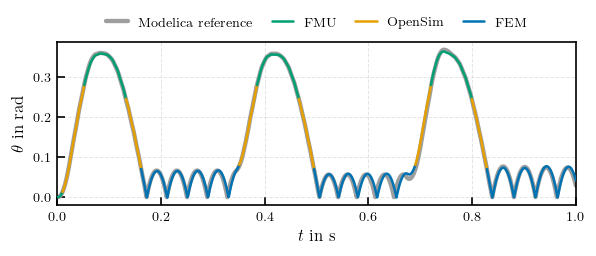

In [14]:
# F3a - the whole horizon. The trajectory itself is coloured by the model that
# was active, so the switches need no separate marking, and the grey rail
# underneath is the monolithic reference.
fig, ax = plt.subplots(figsize=(0.86 * FULL_WIDTH, 0.38 * FULL_WIDTH))

ax.plot(ref["time"], ref["theta"], label="Modelica reference", **REFERENCE_STYLE)

drawn = set()
for mode, t_seg, y_seg in mode_segments(t_plant, theta_plant, intervals):
    ax.plot(t_seg, y_seg, color=MODEL_COLORS[mode], linewidth=1.5, solid_capstyle="round",
            zorder=3, label=mode if mode not in drawn else None)
    drawn.add(mode)

ax.set_xlim(SCENARIO.t0, SCENARIO.t_end)
ax.set_xlabel(r"$t$ in $\mathrm{s}$")
ax.set_ylabel(r"$\theta$ in $\mathrm{rad}$")
ax.grid(True, **GRID_STYLE)
# Above the axes: at this aspect ratio any in-axes corner collides with either
# the launch ramp or the bounce envelope.
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=4, fontsize=8,
          frameon=False, handlelength=1.6, columnspacing=1.4)

fig.tight_layout()
fig.savefig(OUT_DIR / "F3a_trajectory.pdf", bbox_inches="tight")
plt.show()


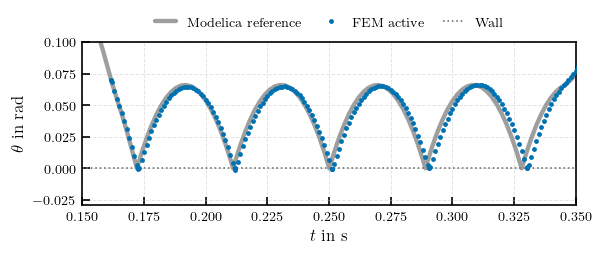

In [15]:
# F3b - the contact window, FEM only. Everything outside the FEM intervals is
# dropped: during the bounces the deformable model is the active one, and the
# question this figure answers is whether it tracks the rigid reference with
# ideal elastic contact through the impact sequence.
fig, ax = plt.subplots(figsize=(0.86 * FULL_WIDTH, 0.38 * FULL_WIDTH))

ax.plot(ref["time"], ref["theta"], label="Modelica reference", **REFERENCE_STYLE)

fem_intervals = [iv for iv in intervals if iv[2] == "FEM"]
drawn = False
for mode, t_seg, y_seg in mode_segments(t_plant, theta_plant, fem_intervals):
    ax.plot(t_seg, y_seg, color=MODEL_COLORS["FEM"], linestyle="None", marker="o", markersize=2, zorder=3, label=None if drawn else "FEM active")
    drawn = True

ax.axhline(0.0, label="Wall", **WALL_STYLE)

ax.set_xlim(0.15, 0.35)
# Scaled to the bounce envelope inside the window, so the impacts fill the axes.
inside = (t_plant >= WINDOW[0]) & (t_plant <= WINDOW[1])
top = float(np.max(theta_plant[inside])) if inside.any() else 0.05
ax.set_ylim(-0.08 * top, 0.1)
ax.set_xlabel(r"$t$ in $\mathrm{s}$")
ax.set_ylabel(r"$\theta$ in $\mathrm{rad}$")
ax.grid(True, **GRID_STYLE)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=3, fontsize=8,
          frameon=False, handlelength=1.6, columnspacing=1.4)

fig.tight_layout()
fig.savefig(OUT_DIR / "F3b_contact_window.pdf", bbox_inches="tight")
plt.show()


## Reading the result

**The enforced columns are a contract check, not a quality measure.** They cannot
show a violation in a run that completed, because the transaction would have
rolled back instead.

**The unenforced columns are the result.** `d_alpha` and `elastic_lost` are what
the canonical interface cannot carry: acceleration is not part of it, and the
strain energy in the FEM state has no counterpart in a rigid model. That loss is
by design, and this table is where its size is stated.

**Placement is off-grid by construction.** Read `min off_grid` against the macro
step: the switches sit strictly between communication points, which is what
separates this from switching on the grid.

The trajectory error against the monolithic reference is *not* a placement
measurement — the reference never switches, so it mixes model mismatch with
placement. `05_placement.ipynb` isolates placement against a refined reference of
the same configuration.